In [1]:
# fashion_mnist
import tensorflow as tf
from tensorflow import keras
import numpy as np

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32')
x_test  = x_test.astype('float32')

x_train = tf.reshape(x_train, (-1, 3072))
x_test  = tf.reshape(x_test, (-1, 3072))

# data normalization
x_train = x_train/255.0
x_test  = x_test/255.0

print(x_train.shape)
print(x_test.shape)

print(y_train.shape)
print(y_test.shape)

2022-11-29 23:26:18.024380: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-29 23:26:18.027997: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-29 23:26:18.028088: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-29 23:26:18.028351: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

(50000, 3072)
(10000, 3072)
(50000, 1)
(10000, 1)


2022-11-29 23:26:18.649299: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 614400000 exceeds 10% of free system memory.


In [2]:
import tensorflow as tf
import tensorflow.keras as keras

# set seed
tf.random.set_seed(1234)

# create model
model = keras.Sequential()
model.add(keras.Input(shape=(3072,)))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               393344    
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 10)                1290      
                                                                 
Total params: 411,146
Trainable params: 411,146
Non-trainable params: 0
_________________________________________________________________


In [3]:
# optimizer and loss
model.compile(optimizer='adadelta', 
              loss='sparse_categorical_crossentropy', 
              metrics=['sparse_categorical_accuracy'])

# training
batch_size = 256
history = model.fit(x_train, y_train, batch_size,
                    validation_data=(x_test, y_test),
                    epochs=500, verbose=2)

2022-11-29 23:26:19.481617: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 614400000 exceeds 10% of free system memory.


Epoch 1/500


2022-11-29 23:26:20.351571: I tensorflow/stream_executor/cuda/cuda_blas.cc:1774] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


196/196 - 1s - loss: 2.3689 - sparse_categorical_accuracy: 0.1004 - val_loss: 2.3245 - val_sparse_categorical_accuracy: 0.1028 - 1s/epoch - 6ms/step
Epoch 2/500
196/196 - 0s - loss: 2.2957 - sparse_categorical_accuracy: 0.1210 - val_loss: 2.2739 - val_sparse_categorical_accuracy: 0.1367 - 384ms/epoch - 2ms/step
Epoch 3/500
196/196 - 0s - loss: 2.2527 - sparse_categorical_accuracy: 0.1571 - val_loss: 2.2400 - val_sparse_categorical_accuracy: 0.1704 - 392ms/epoch - 2ms/step
Epoch 4/500
196/196 - 0s - loss: 2.2226 - sparse_categorical_accuracy: 0.1880 - val_loss: 2.2147 - val_sparse_categorical_accuracy: 0.1990 - 387ms/epoch - 2ms/step
Epoch 5/500
196/196 - 0s - loss: 2.1988 - sparse_categorical_accuracy: 0.2121 - val_loss: 2.1930 - val_sparse_categorical_accuracy: 0.2097 - 385ms/epoch - 2ms/step
Epoch 6/500
196/196 - 0s - loss: 2.1790 - sparse_categorical_accuracy: 0.2221 - val_loss: 2.1749 - val_sparse_categorical_accuracy: 0.2228 - 382ms/epoch - 2ms/step
Epoch 7/500
196/196 - 0s - loss

Epoch 51/500
196/196 - 0s - loss: 1.8936 - sparse_categorical_accuracy: 0.3387 - val_loss: 1.8993 - val_sparse_categorical_accuracy: 0.3356 - 386ms/epoch - 2ms/step
Epoch 52/500
196/196 - 0s - loss: 1.8910 - sparse_categorical_accuracy: 0.3390 - val_loss: 1.8967 - val_sparse_categorical_accuracy: 0.3367 - 378ms/epoch - 2ms/step
Epoch 53/500
196/196 - 0s - loss: 1.8884 - sparse_categorical_accuracy: 0.3405 - val_loss: 1.8942 - val_sparse_categorical_accuracy: 0.3376 - 379ms/epoch - 2ms/step
Epoch 54/500
196/196 - 0s - loss: 1.8859 - sparse_categorical_accuracy: 0.3406 - val_loss: 1.8917 - val_sparse_categorical_accuracy: 0.3389 - 383ms/epoch - 2ms/step
Epoch 55/500
196/196 - 0s - loss: 1.8834 - sparse_categorical_accuracy: 0.3423 - val_loss: 1.8894 - val_sparse_categorical_accuracy: 0.3416 - 383ms/epoch - 2ms/step
Epoch 56/500
196/196 - 0s - loss: 1.8811 - sparse_categorical_accuracy: 0.3433 - val_loss: 1.8871 - val_sparse_categorical_accuracy: 0.3410 - 380ms/epoch - 2ms/step
Epoch 57/5

...

Epoch 251/500
196/196 - 0s - loss: 1.6774 - sparse_categorical_accuracy: 0.4200 - val_loss: 1.6878 - val_sparse_categorical_accuracy: 0.4112 - 380ms/epoch - 2ms/step
Epoch 252/500
196/196 - 0s - loss: 1.6769 - sparse_categorical_accuracy: 0.4198 - val_loss: 1.6871 - val_sparse_categorical_accuracy: 0.4135 - 386ms/epoch - 2ms/step
Epoch 253/500
196/196 - 0s - loss: 1.6763 - sparse_categorical_accuracy: 0.4204 - val_loss: 1.6864 - val_sparse_categorical_accuracy: 0.4113 - 390ms/epoch - 2ms/step
Epoch 254/500
196/196 - 0s - loss: 1.6756 - sparse_categorical_accuracy: 0.4205 - val_loss: 1.6859 - val_sparse_categorical_accuracy: 0.4139 - 416ms/epoch - 2ms/step
Epoch 255/500
196/196 - 0s - loss: 1.6751 - sparse_categorical_accuracy: 0.4206 - val_loss: 1.6853 - val_sparse_categorical_accuracy: 0.4144 - 397ms/epoch - 2ms/step
Epoch 256/500
196/196 - 0s - loss: 1.6745 - sparse_categorical_accuracy: 0.4210 - val_loss: 1.6848 - val_sparse_categorical_accuracy: 0.4128 - 393ms/epoch - 2ms/step
Epoc

Epoch 301/500
196/196 - 0s - loss: 1.6490 - sparse_categorical_accuracy: 0.4293 - val_loss: 1.6610 - val_sparse_categorical_accuracy: 0.4227 - 383ms/epoch - 2ms/step
Epoch 302/500
196/196 - 0s - loss: 1.6484 - sparse_categorical_accuracy: 0.4305 - val_loss: 1.6607 - val_sparse_categorical_accuracy: 0.4234 - 387ms/epoch - 2ms/step
Epoch 303/500
196/196 - 0s - loss: 1.6479 - sparse_categorical_accuracy: 0.4306 - val_loss: 1.6602 - val_sparse_categorical_accuracy: 0.4227 - 382ms/epoch - 2ms/step
Epoch 304/500
196/196 - 0s - loss: 1.6473 - sparse_categorical_accuracy: 0.4312 - val_loss: 1.6597 - val_sparse_categorical_accuracy: 0.4227 - 385ms/epoch - 2ms/step
Epoch 305/500
196/196 - 0s - loss: 1.6468 - sparse_categorical_accuracy: 0.4307 - val_loss: 1.6592 - val_sparse_categorical_accuracy: 0.4228 - 385ms/epoch - 2ms/step
Epoch 306/500
196/196 - 0s - loss: 1.6463 - sparse_categorical_accuracy: 0.4312 - val_loss: 1.6589 - val_sparse_categorical_accuracy: 0.4235 - 377ms/epoch - 2ms/step
Epoc

Epoch 351/500
196/196 - 0s - loss: 1.6248 - sparse_categorical_accuracy: 0.4390 - val_loss: 1.6392 - val_sparse_categorical_accuracy: 0.4295 - 387ms/epoch - 2ms/step
Epoch 352/500
196/196 - 0s - loss: 1.6242 - sparse_categorical_accuracy: 0.4397 - val_loss: 1.6390 - val_sparse_categorical_accuracy: 0.4291 - 415ms/epoch - 2ms/step
Epoch 353/500
196/196 - 0s - loss: 1.6239 - sparse_categorical_accuracy: 0.4396 - val_loss: 1.6383 - val_sparse_categorical_accuracy: 0.4291 - 396ms/epoch - 2ms/step
Epoch 354/500
196/196 - 0s - loss: 1.6234 - sparse_categorical_accuracy: 0.4395 - val_loss: 1.6382 - val_sparse_categorical_accuracy: 0.4289 - 387ms/epoch - 2ms/step
Epoch 355/500
196/196 - 0s - loss: 1.6229 - sparse_categorical_accuracy: 0.4393 - val_loss: 1.6378 - val_sparse_categorical_accuracy: 0.4305 - 390ms/epoch - 2ms/step
Epoch 356/500
196/196 - 0s - loss: 1.6226 - sparse_categorical_accuracy: 0.4403 - val_loss: 1.6373 - val_sparse_categorical_accuracy: 0.4314 - 388ms/epoch - 2ms/step
Epoc

Epoch 401/500
196/196 - 0s - loss: 1.6039 - sparse_categorical_accuracy: 0.4458 - val_loss: 1.6207 - val_sparse_categorical_accuracy: 0.4358 - 388ms/epoch - 2ms/step
Epoch 402/500
196/196 - 0s - loss: 1.6035 - sparse_categorical_accuracy: 0.4462 - val_loss: 1.6204 - val_sparse_categorical_accuracy: 0.4358 - 383ms/epoch - 2ms/step
Epoch 403/500
196/196 - 0s - loss: 1.6031 - sparse_categorical_accuracy: 0.4458 - val_loss: 1.6201 - val_sparse_categorical_accuracy: 0.4356 - 377ms/epoch - 2ms/step
Epoch 404/500
196/196 - 0s - loss: 1.6027 - sparse_categorical_accuracy: 0.4457 - val_loss: 1.6197 - val_sparse_categorical_accuracy: 0.4355 - 380ms/epoch - 2ms/step
Epoch 405/500
196/196 - 0s - loss: 1.6024 - sparse_categorical_accuracy: 0.4464 - val_loss: 1.6195 - val_sparse_categorical_accuracy: 0.4360 - 379ms/epoch - 2ms/step
Epoch 406/500
196/196 - 0s - loss: 1.6019 - sparse_categorical_accuracy: 0.4467 - val_loss: 1.6190 - val_sparse_categorical_accuracy: 0.4365 - 381ms/epoch - 2ms/step
Epoc

Epoch 451/500
196/196 - 0s - loss: 1.5853 - sparse_categorical_accuracy: 0.4525 - val_loss: 1.6046 - val_sparse_categorical_accuracy: 0.4414 - 389ms/epoch - 2ms/step
Epoch 452/500
196/196 - 0s - loss: 1.5849 - sparse_categorical_accuracy: 0.4533 - val_loss: 1.6045 - val_sparse_categorical_accuracy: 0.4403 - 383ms/epoch - 2ms/step
Epoch 453/500
196/196 - 0s - loss: 1.5846 - sparse_categorical_accuracy: 0.4530 - val_loss: 1.6041 - val_sparse_categorical_accuracy: 0.4417 - 371ms/epoch - 2ms/step
Epoch 454/500
196/196 - 0s - loss: 1.5843 - sparse_categorical_accuracy: 0.4527 - val_loss: 1.6038 - val_sparse_categorical_accuracy: 0.4412 - 386ms/epoch - 2ms/step
Epoch 455/500
196/196 - 0s - loss: 1.5839 - sparse_categorical_accuracy: 0.4531 - val_loss: 1.6036 - val_sparse_categorical_accuracy: 0.4410 - 386ms/epoch - 2ms/step
Epoch 456/500
196/196 - 0s - loss: 1.5835 - sparse_categorical_accuracy: 0.4537 - val_loss: 1.6033 - val_sparse_categorical_accuracy: 0.4415 - 376ms/epoch - 2ms/step
Epoc

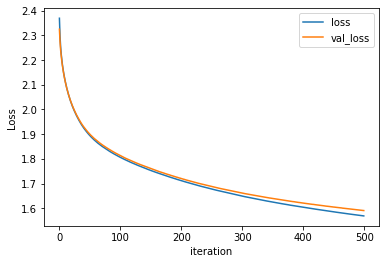

In [4]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('iteration')
plt.ylabel('Loss')
plt.legend()

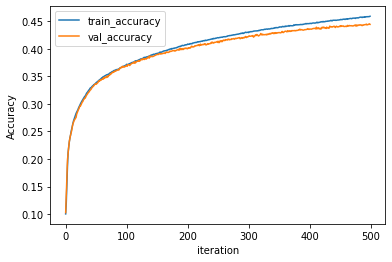

In [5]:
import matplotlib.pyplot as plt

plt.plot(history.history['sparse_categorical_accuracy'], label='train_accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='val_accuracy')
plt.xlabel('iteration')
plt.ylabel('Accuracy')
plt.legend()